# Bose-Hubbard Physics from Continuous-Space VMC

This notebook trains a neural-network VMC ansatz for bosons in a 1D optical lattice
and compares the result to the **Bose-Hubbard (BH) model** in second quantization.

## The two descriptions

**Continuous-space Hamiltonian** (what VMC simulates):

$$H = -\frac{1}{2}\sum_i \frac{\partial^2}{\partial x_i^2}
    + V_0 \sum_i \sin^2\!\left(\frac{\pi x_i}{a}\right)
    + g_{\rm 1D} \sum_{i<j} \delta(x_i - x_j)$$

The lattice potential $V_0\sin^2(\pi x/a)$ has period $a$ (lattice spacing).
The $\delta$-function contact interaction is approximated by a narrow Gaussian.

**Bose-Hubbard model** (2nd quantization, tight-binding):

$$H_{\rm BH} = -t \sum_{\langle i,j \rangle} (a^\dagger_i a_j + {\rm h.c.})
    + \frac{U}{2} \sum_i n_i(n_i - 1)$$

This emerges from the continuous model when the lattice is deep and atoms sit in the
lowest band. The effective parameters $t$ and $U$ come from the single-particle band
structure and the on-site Wannier integral.

## Analytical limits

For $N$ bosons on $N_{\rm sites}$ sites at **unit filling** ($\bar{n} = 1$) with PBC:

| Regime | Condition | Ground-state energy |
|---|---|---|
| **Superfluid** (all bosons condense to $k=0$) | $U/t \to 0$ | $E_{\rm SF} = -2Nt$ |
| **Mott insulator** (one boson per site) | $U/t \to \infty$ | $E_{\rm MI} \approx -4Nt^2/U$ |

The superfluid result is exact (free bosons all in the $k=0$ Bloch state).
The MI result is a second-order perturbation correction: each bond can virtually
create a doublon-hole pair with Bose factor $\sqrt{2}$ at energy cost $U$.

The quantum phase transition (thermodynamic limit, 1D) occurs at $(U/t)_c \approx 3.37$.

---
## 1. Imports

In [3]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
import flax.linen as nn
import matplotlib.pyplot as plt
from flax import struct
from scipy.linalg import eigh

from qvarnet import train
from qvarnet.config.training_setup import TrainingConfig, SamplingConfig
from qvarnet.config.coord_mode import LabCoords
from qvarnet.probability import build_prob_fn
from qvarnet.samplers import sample_and_process
from qvarnet import NoBoundary, PeriodicBoundary, BoundaryHamiltonian
from qvarnet.models import LogWavefunction, DeepSet, MLP, TransformerWavefunction

print('JAX devices:', jax.devices())

JAX devices: [CudaDevice(id=0)]


---
## 2. System parameters

We use natural units: $\hbar = m = 1$, so the recoil energy is
$E_R = \frac{\hbar^2}{2m}\left(\frac{\pi}{a}\right)^2 = \frac{\pi^2}{2a^2}$.

The ratio $V_0/E_R$ controls the lattice depth. For $V_0/E_R \gtrsim 3$ the
single-band approximation is valid and the BH model is a good description.

The contact interaction strength $g_{\rm 1D}$ sets the $U/t$ ratio.
We approximate the $\delta$-function by a Gaussian of width $\sigma \ll a$:
$$g_{\rm 1D}\,\delta(x) \approx \frac{g_{\rm 1D}}{\sigma\sqrt{2\pi}} e^{-x^2/(2\sigma^2)}$$

In [4]:
is_unit_filling = True

# ── Lattice geometry ──────────────────────────────────────────────────────────
N       = 4          # bosons (unit filling: N = N_SITES)
N_SITES = N          # lattice sites
N_DIM   = 1          # spatial dimensions per particle (1D)
A       = 1.0        # lattice spacing
L       = N_SITES * A  # box size with PBC

# ── Lattice depth ─────────────────────────────────────────────────────────────
E_R     = np.pi**2 / (2 * A**2)   # recoil energy
V0_ER   = 10.0                      # lattice depth in units of E_R
V0      = V0_ER * E_R              # lattice depth in natural units

# ── Contact interaction (Gaussian approx of δ-function) ───────────────────────
G_1D    = 1.0        # 1D interaction strength  ← sweep this to go SF → MI
SIGMA   = 0.1 * A   # Gaussian width (should be ≪ a for δ-function limit)

print(f"Lattice: {N_SITES} sites, spacing a={A}, L={L}")
print(f"Filling: N={N} bosons, n̄ = {N/N_SITES:.1f} per site")
print(f"Lattice depth: V0 = {V0:.2f}  ({V0_ER:.1f} E_R)")
print(f"Contact interaction: g_1D = {G_1D}, σ = {SIGMA:.3f}")

Lattice: 4 sites, spacing a=1.0, L=4.0
Filling: N=4 bosons, n̄ = 1.0 per site
Lattice depth: V0 = 49.35  (10.0 E_R)
Contact interaction: g_1D = 1.0, σ = 0.100


---
## 3. Effective hopping $t$ from the band structure

For a particle in $V(x) = V_0\sin^2(\pi x/a) = \frac{V_0}{2}(1 - \cos(2\pi x/a))$,
we solve the Bloch eigenvalue problem using a **plane-wave basis**.

With Bloch states $\psi_k(x) = e^{ikx}u_k(x)$ and
$u_k(x) = \frac{1}{\sqrt{a}}\sum_G c_G^{(k)} e^{iGx}$
($G = 2\pi n/a$ reciprocal lattice vectors), the Hamiltonian matrix becomes:

$$(H_k)_{mn} = \frac{1}{2}(k+G_m)^2\delta_{mn} + \tilde{V}_{m-n}$$

where $\tilde{V}_0 = V_0/2$ and $\tilde{V}_{\pm 1} = -V_0/4$ (the only nonzero
Fourier components of the cosine lattice).

### Extracting $t$ from the band: why $t = (\varepsilon_{\pi/a} - \varepsilon_0)/4$

When the lattice is deep enough, the lowest Bloch band has an almost-perfect cosine shape:

$$\varepsilon_k \approx \varepsilon_0 - 2t\cos(ka)$$

This is the tight-binding (nearest-neighbour) dispersion. Evaluate it at the two
special points:

| $k$ | $\cos(ka)$ | $\varepsilon_k$ |
|---|---|---|
| $0$ (zone centre) | $+1$ | $\varepsilon_0 - 2t$ ← **minimum** |
| $\pi/a$ (zone edge) | $-1$ | $\varepsilon_0 + 2t$ ← **maximum** |

Subtracting the two:

$$\varepsilon_{\pi/a} - \varepsilon_0 = 4t \quad\Longrightarrow\quad t = \frac{\varepsilon_{\pi/a} - \varepsilon_0}{4}$$

The denominator 4 comes from the factor of 2 in the amplitude ($2t$) times the
factor of 2 in $\cos(0) - \cos(\pi) = 1 - (-1) = 2$.

### Why the zone-edge is at index `N_SITES // 2`

For a ring of $N_{\rm sites}$ sites with lattice spacing $a$, the allowed
Bloch momenta (periodic boundary conditions) are:

$$k_n = \frac{2\pi n}{N_{\rm sites}\, a}, \qquad n = 0, 1, \ldots, N_{\rm sites}-1$$

To find which index $n^\star$ gives the zone-edge $k_{n^\star} = \pi/a$:

$$\frac{2\pi\, n^\star}{N_{\rm sites}\, a} = \frac{\pi}{a}
\quad\Longrightarrow\quad
n^\star = \frac{N_{\rm sites}}{2}$$

So **`band[N_SITES // 2]` is always the zone-edge energy**, regardless of system size.
For $N_{\rm sites} = 4$ this is index 2; for $N_{\rm sites} = 6$ it would be index 3, etc.

> **Pitfall:** writing `band[2]` instead of `band[N_SITES // 2]` hard-codes the
> assumption $N_{\rm sites} = 4$. The tight-binding fit would use the wrong $k$-point
> as the zone edge, giving a wrong $t$ and a red-dashed curve that visibly disagrees
> with the exact band for any other system size.

Note: this requires $N_{\rm sites}$ to be **even**, which is always the case for a
ring at unit filling with PBC (odd $N_{\rm sites}$ would not have an exact zone-edge
point in the grid, but such systems are uncommon in this context).

Lowest Bloch band:   [14.049  14.2339 14.4277 14.2339]
Band width:          0.3787  (= 4t for pure cosine band)
Effective hopping:   t   = 0.094683
On-site energy:      ε₀  = 14.236118   (N·ε₀ = 56.9445)


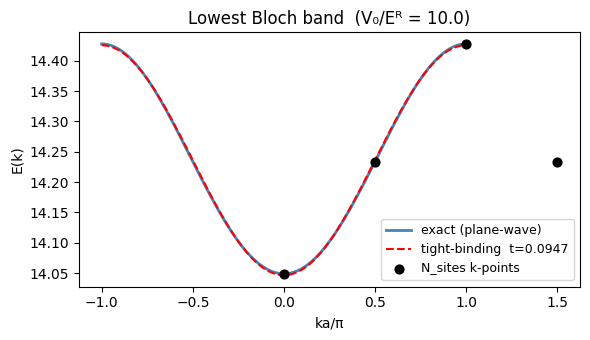

In [5]:
def bloch_band_lowest(k, V0, a=1.0, n_pw=20):
    """Lowest Bloch energy at wavevector k using a plane-wave basis."""
    n_vec = np.arange(-n_pw, n_pw + 1)
    G     = 2 * np.pi * n_vec / a
    N_pw  = len(n_vec)

    # Kinetic energy + uniform part of V
    H = np.diag(0.5 * (k + G)**2 + V0 / 2)

    # Cosine lattice: couples G_n ↔ G_{n±1} with matrix element −V0/4
    for i in range(N_pw - 1):
        H[i, i + 1] -= V0 / 4
        H[i + 1, i] -= V0 / 4

    return np.linalg.eigvalsh(H)[0]


# Bloch momenta for N_SITES sites (first Brillouin zone)
k_bz = 2 * np.pi * np.arange(N_SITES) / (N_SITES * A)

band = np.array([bloch_band_lowest(k, V0, A) for k in k_bz])

# Tight-binding fit: E(k) = E0 − 2t cos(ka)
T_EFF = (band[N_SITES // 2] - band[0]) / 4

# On-site energy ε₀ = ⟨w₀|T + V_latt|w₀⟩ = (1/N_sites) Σ_k E_k
# The BH model measures energies relative to this: H_BH = N·ε₀ + H_BH_relative.
# VMC computes the full energy including N·ε₀, so we add it back to BH predictions.
E0_BAND = float(np.mean(band)) # FIRST FOURIER COMPONENT OF THE BAND

print(f"Lowest Bloch band:   {np.round(band, 4)}")
print(f"Band width:          {band.max() - band.min():.4f}  (= 4t for pure cosine band)")
print(f"Effective hopping:   t   = {T_EFF:.6f}")
print(f"On-site energy:      ε₀  = {E0_BAND:.6f}   (N·ε₀ = {N*E0_BAND:.4f})")

# Plot: band dispersion vs tight-binding fit
k_dense = np.linspace(-np.pi / A, np.pi / A, 200)
E_tb    = E0_BAND - 2 * T_EFF * np.cos(k_dense * A)
E_exact = np.array([bloch_band_lowest(k, V0, A) for k in k_dense])

plt.figure(figsize=(6, 3.5))
plt.plot(k_dense * A / np.pi, E_exact, 'steelblue', lw=2, label='exact (plane-wave)')
plt.plot(k_dense * A / np.pi, E_tb,    'r--',       lw=1.5, label=f'tight-binding  t={T_EFF:.4f}')
plt.scatter(k_bz * A / np.pi, band, color='k', zorder=5, s=40, label='N_sites k-points')
plt.xlabel('ka/π'); plt.ylabel('E(k)')
plt.title(f'Lowest Bloch band  (V₀/Eᴿ = {V0_ER})')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

---
## 4. Effective on-site interaction $U$ from Wannier functions

The Wannier function centred at site $j=0$ is the Fourier transform of the Bloch states
over the lowest band:
$$w(x) = \frac{1}{\sqrt{N_{\rm sites}}} \sum_k e^{0} \psi_k(x)
       = \frac{1}{\sqrt{N_{\rm sites}}} \sum_k \sum_G c^{(k)}_G
         \frac{e^{i(k+G)x}}{\sqrt{L}}$$

The on-site interaction energy is the Hubbard $U$ parameter:
$$U = g_{\rm 1D} \int_0^L |w(x)|^4\, dx$$

We also compute an approximate $U$ using the Gaussian Wannier approximation valid for
deep lattices: $w(x) \approx (\pi\sigma_w^2)^{-1/4} e^{-x^2/(2\sigma_w^2)}$ with
$\sigma_w = \frac{a}{\pi}(E_R/V_0)^{1/4}$, giving
$U_{\rm approx} = g_{\rm 1D}/(\sigma_w\sqrt{2\pi})$.

Wannier norm check: ∫|w|² = 0.9883  (should be 1)
∫|w|⁴ dx = 2.0012
Effective U = g_1D × ∫|w|⁴ = 2.0012
Gaussian-Wannier approx U ≈ 2.2287

Effective U/t = 21.14


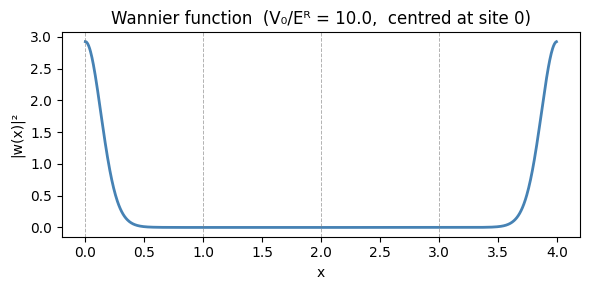

In [6]:
def compute_wannier(V0, a=1.0, N_sites=4, n_pw=20, M_grid=1000):
    """Compute Wannier function |w(x)|² and ∫|w|⁴ dx numerically."""
    k_vals  = 2 * np.pi * np.arange(N_sites) / (N_sites * a)
    n_vec   = np.arange(-n_pw, n_pw + 1)
    G_vecs  = 2 * np.pi * n_vec / a
    N_pw    = len(n_vec)
    L_total = N_sites * a

    # For each k: get the lowest Bloch eigenstate (plane-wave coefficients)
    bloch_coeff = []
    for k in k_vals:
        H = np.diag(0.5 * (k + G_vecs)**2 + V0 / 2)
        for i in range(N_pw - 1):
            H[i, i + 1] -= V0 / 4
            H[i + 1, i] -= V0 / 4
        _, vecs = np.linalg.eigh(H)
        c = vecs[:, 0]  # lowest eigenvector; may have global phase
        # Fix phase: choose c real and positive at G=0
        c = c * np.sign(c[n_pw])
        bloch_coeff.append(c)

    # Build Wannier function w(x) = (1/√N) Σ_k ψ_k(x), centred at site 0
    # ψ_k(x) = (1/√L) Σ_G c_G^(k) exp(i(k+G)x)
    x = np.linspace(0, L_total, M_grid, endpoint=False)
    w_x = np.zeros(M_grid, dtype=complex)
    for ik, k in enumerate(k_vals):
        for ig, (G_val, c) in enumerate(zip(G_vecs, bloch_coeff[ik])):
            w_x += c * np.exp(1j * (k + G_val) * x)
    w_x /= np.sqrt(N_sites * L_total)  # normalisation: ∫|w|² = 1

    # Check normalisation
    norm = np.trapezoid(np.abs(w_x)**2, x)

    # ∫|w(x)|⁴ dx
    int_w4 = np.trapezoid(np.abs(w_x)**4, x)

    return x, np.abs(w_x)**2, int_w4, float(norm)


x_w, w2_x, int_w4, norm_check = compute_wannier(V0, A, N_SITES)

# Effective U for our Gaussian interaction with amplitude g_1D/σ√(2π)
# The contact-interaction limit: U = g_1D * ∫|w(x)|⁴ dx
# Our Gaussian approximation: g_1D * ∫|w(x)|⁴ * G(σ) dx
# For σ ≪ a, ∫ G(σ,r) |w(r+x)|² |w(x)|² dx → |w(x)|² at each x → ∫|w|⁴
U_EFF = G_1D * int_w4  # effective Hubbard U

# Gaussian-Wannier approximation (valid for deep lattices)
sigma_w_approx = A / np.pi * (E_R / V0)**0.25
U_approx = G_1D / (sigma_w_approx * np.sqrt(2 * np.pi))

print(f"Wannier norm check: ∫|w|² = {norm_check:.4f}  (should be 1)")
print(f"∫|w|⁴ dx = {int_w4:.4f}")
print(f"Effective U = g_1D × ∫|w|⁴ = {U_EFF:.4f}")
print(f"Gaussian-Wannier approx U ≈ {U_approx:.4f}")
print(f"\nEffective U/t = {U_EFF / T_EFF:.2f}")

plt.figure(figsize=(6, 3))
plt.plot(x_w, w2_x, 'steelblue', lw=2)
# Mark site centres
for j in range(N_SITES):
    plt.axvline(j * A, color='gray', ls='--', lw=0.7, alpha=0.6)
plt.xlabel('x'); plt.ylabel('|w(x)|²')
plt.title(f'Wannier function  (V₀/Eᴿ = {V0_ER},  centred at site 0)')
plt.tight_layout(); plt.show()

---
## 5. Bose-Hubbard analytical limits

With the effective parameters $(t, U)$ from the lattice, the BH ground-state energy
is bounded by the two limiting expressions:

### Superfluid limit ($U \to 0$)

All $N$ bosons condense into the $k=0$ Bloch state, whose energy is
$\varepsilon_0 = -2t$. The total energy is:
$$E_{\rm SF} = N \varepsilon_0 = -2Nt$$

This is **exact** for $U=0$ — it is the ground state of free bosons on the lattice.
Including weak interactions at first order: $E_{\rm SF} \approx -2Nt + \frac{UN(N-1)}{2N_{\rm sites}}$.

### Mott insulator limit ($U \gg t$, unit filling)

The zero-order ground state is the Mott state $|\Psi_0\rangle = |1,1,\ldots,1\rangle$
with energy $E_0 = 0$. Perturbation theory in $t/U$ gives:

$$E_{\rm MI} \approx -\frac{4Nt^2}{U}$$

The factor 4 = 2 (Bose factor $\sqrt{2}^2$) × 2 (both hop directions per bond),
and the number of bonds equals $N_{\rm sites}$ in 1D with PBC.

### Crossover

The quantum phase transition in 1D occurs at $(U/t)_c \approx 3.37$ (DMRG).
For our finite system ($N_{\rm sites}=4$) there is no sharp transition, only a
smooth crossover. We also implement **exact diagonalization** (ED) of the BH model
for this small system to get the exact finite-size ground-state energy.

Effective parameters:  t = 0.09468,  U = 2.0012,  U/t = 21.14

BH relative energies (textbook, no lattice offset):
  SF  E_rel = -2Nt        = -0.7575
  MI  E_rel ≈ -4Nt²/U    = -0.0717

Full energies (including N·ε₀ = 56.9445; comparable to VMC):
  SF  E_SF  = 56.1870
  MI  E_MI  = 56.8728
  ED  E_ED  = 56.8713  (BH exact diag + N·ε₀)


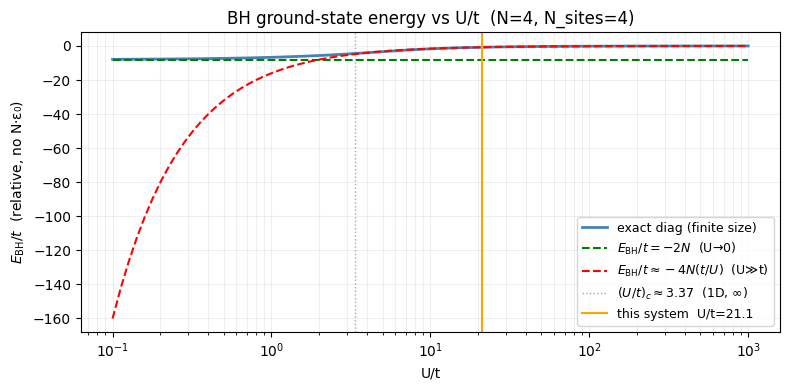

In [7]:
# ── BH relative energies (standard BH, no on-site offset) ────────────────────
# These are what you see in textbooks: energies measured relative to N·ε₀
E_SF_REL = -2 * N * T_EFF             # superfluid (all in k=0): E_BH = -2Nt
E_MI_REL = -4 * N * T_EFF**2 / U_EFF  # Mott ins. (2nd order):  E_BH ≈ -4Nt²/U

# ── Full energies (what VMC measures) ────────────────────────────────────────
# E_VMC ≈ N·ε₀ + E_BH_relative,   so BH predictions must include N·ε₀
E_SF = N * E0_BAND + E_SF_REL
E_MI = N * E0_BAND + E_MI_REL

print(f"Effective parameters:  t = {T_EFF:.5f},  U = {U_EFF:.4f},  U/t = {U_EFF/T_EFF:.2f}")
print()
print(f"BH relative energies (textbook, no lattice offset):")
print(f"  SF  E_rel = -2Nt        = {E_SF_REL:.4f}")
print(f"  MI  E_rel ≈ -4Nt²/U    = {E_MI_REL:.4f}")
print()
print(f"Full energies (including N·ε₀ = {N*E0_BAND:.4f}; comparable to VMC):")
print(f"  SF  E_SF  = {E_SF:.4f}")
print(f"  MI  E_MI  = {E_MI:.4f}")

# ── Exact diagonalization of the BH model ─────────────────────────────────────
from itertools import product as iproduct

def bh_exact_diag(N_bosons, N_sites, t, U):
    """Exact diagonalization of the 1D BH model with PBC.
    Returns E_BH_relative (does not include N·ε₀).
    """
    fock_states = [s for s in iproduct(range(N_bosons + 1), repeat=N_sites)
                   if sum(s) == N_bosons]
    # print(f"Fock states (dim={len(fock_states)}): {fock_states}")
    dim = len(fock_states)
    state_to_idx = {s: i for i, s in enumerate(fock_states)}

    H = np.zeros((dim, dim))
    for idx, state in enumerate(fock_states):
        n = np.array(state)
        H[idx, idx] += 0.5 * U * np.sum(n * (n - 1)) # on-site interaction
        for i in range(N_sites):
            j = (i + 1) % N_sites # PBC: site j is the neighbour of site i
            if n[i] > 0:
                new_n = list(n); new_n[i] -= 1; new_n[j] += 1 # boson hops from i to j
                me = -t * np.sqrt(n[i]) * np.sqrt(n[j] + 1) # matrix element for boson hopping
                jdx = state_to_idx.get(tuple(new_n))
                if jdx is not None:
                    H[idx, jdx] += me; H[jdx, idx] += me

    return np.linalg.eigvalsh(H)[0]


E_ED_REL = bh_exact_diag(N, N_SITES, T_EFF, U_EFF)   # BH_relative
E_ED     = N * E0_BAND + E_ED_REL                     # full energy

print(f"  ED  E_ED  = {E_ED:.4f}  (BH exact diag + N·ε₀)")

# ── Phase diagram vs U/t (relative energies, units of t) ─────────────────────
ut_range  = np.logspace(-1, 3, 80)
E_sf_t    = -2 * N * np.ones_like(ut_range)           # E/t = −2N
E_mi_t    = -4 * N / ut_range                          # E/t ≈ −4N/(U/t)
E_ed_t    = np.array([bh_exact_diag(N, N_SITES, 1.0, ut) for ut in ut_range])

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(ut_range, E_ed_t, 'steelblue', lw=2,  label='exact diag (finite size)')
ax.semilogx(ut_range, E_sf_t, 'g--',       lw=1.5, label=r'$E_{\rm BH}/t = -2N$  (U→0)')
ax.semilogx(ut_range, E_mi_t, 'r--',       lw=1.5, label=r'$E_{\rm BH}/t \approx -4N(t/U)$  (U≫t)')
ax.axvline(3.37, color='gray', ls=':', lw=1, alpha=0.7, label=r'$(U/t)_c \approx 3.37$  (1D, ∞)')
ax.axvline(U_EFF / T_EFF, color='orange', ls='-', lw=1.5, label=f'this system  U/t={U_EFF/T_EFF:.1f}')
ax.set(xlabel='U/t', ylabel='$E_{\\rm BH}/t$  (relative, no N·ε₀)',
       title='BH ground-state energy vs U/t  (N=4, N_sites=4)')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.2)
plt.tight_layout(); plt.show()

---
## 6. Continuous-space Hamiltonian

We define `LatticeBoseHamiltonian` subclassing `BoundaryHamiltonian`.
The only boundary-specific line is `self._min_image(dx)` in the interaction term —
swapping `PeriodicBoundary` for `NoBoundary` requires no other change.

The kinetic energy uses the log-space formula
$T = -\frac{1}{2}\bigl(\Delta\log|\psi| + |\nabla\log|\psi||^2\bigr)$
via automatic differentiation — inherited automatically from `ContinuousHamiltonian`.

In [8]:
@struct.dataclass
class LatticeBoseHamiltonian(BoundaryHamiltonian):
    """N bosons in a 1D optical lattice with contact interactions.

    H = -½ Σᵢ ∂²/∂xᵢ² + V₀ Σᵢ sin²(π xᵢ/a) + (g/σ√2π) Σᵢ<ⱼ exp(−rᵢⱼ²/2σ²)

    The Gaussian approximates a δ-function contact interaction when σ ≪ a.
    `boundary` controls whether pairwise distances use minimum-image (PBC) or
    raw coordinates (free space) — inherited from BoundaryHamiltonian.
    """

    a: float = struct.field(pytree_node=False, default=1.0)    # lattice spacing
    V0: float = 1.0   # lattice depth
    g: float = 1.0    # contact interaction strength g_1D
    sigma: float = struct.field(pytree_node=False, default=0.05)  # Gaussian width

    def potential_energy(self, samples):
        # samples: (batch, N)

        # ── Lattice potential ─────────────────────────────────────────────────
        V_latt = self.V0 * jnp.sum(jnp.sin(jnp.pi * samples / self.a)**2, axis=-1)

        # ── Contact interaction (Gaussian approx of δ) ────────────────────────
        n_part = samples.shape[-1]
        i_idx, j_idx = jnp.triu_indices(n_part, k=1)
        dx = samples[:, i_idx] - samples[:, j_idx]           # raw separations
        dx = self._min_image(dx)                              # minimum image (PBC or identity)
        amplitude = self.g / (self.sigma * jnp.sqrt(2 * jnp.pi))
        V_int = amplitude * jnp.sum(jnp.exp(-dx**2 / (2 * self.sigma**2)), axis=-1)

        return V_latt + V_int

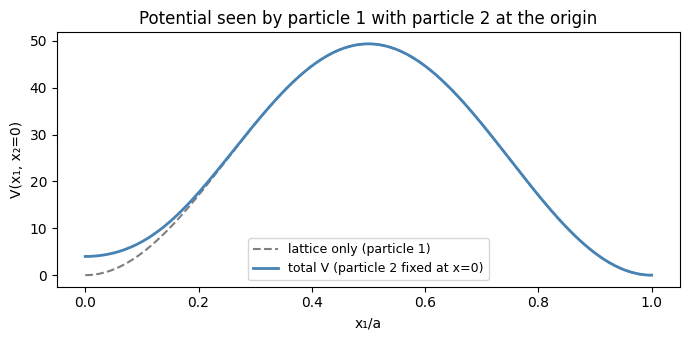

Interaction peak height: 0.000
Expected: g/(σ√2π) = 3.989


In [13]:
# ── Sanity check: plot the potential for 2 particles ─────────────────────────
# Fix particle 2 at site 0 (x=0), sweep particle 1 across one period

boundary = PeriodicBoundary(L=L)
h = LatticeBoseHamiltonian(a=A, V0=V0, g=G_1D, sigma=SIGMA, boundary=boundary)

x1 = np.linspace(0, A, 200)
configs = jnp.stack([jnp.array(x1), jnp.zeros(200)], axis=-1)  # (200, 2)

V_vals = np.array(h.potential_energy(configs))
V_latt_only = V0 * np.sin(np.pi * x1 / A)**2  # just the lattice, no interaction

plt.figure(figsize=(7, 3.5))
plt.plot(x1 / A, V_latt_only, 'k--', lw=1.5, alpha=0.5, label='lattice only (particle 1)')
plt.plot(x1 / A, V_vals,      'steelblue', lw=2,   label='total V (particle 2 fixed at x=0)')
plt.xlabel('x₁/a'); plt.ylabel('V(x₁, x₂=0)')
plt.title('Potential seen by particle 1 with particle 2 at the origin')
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

# The peak at x₁=0 is the Gaussian interaction with particle 2;
# the sin² trap has its minimum at x₁=0 and maximum at x₁=a/2.
print(f"Interaction peak height: {float(np.max(V_vals) - np.max(V_latt_only)):.3f}")
print(f"Expected: g/(σ√2π) = {G_1D / (SIGMA * np.sqrt(2*np.pi)):.3f}")

---
## 7. Wavefunction ansatz

We use `LogWavefunction(transform=boundary, network=DeepSet(...))`.

`PeriodicBoundary` maps each coordinate $x_i \to (\sin(2\pi x_i/L),\,\cos(2\pi x_i/L))$,
giving exact periodicity $\psi(x_i + L) = \psi(x_i)$.

`DeepSet` is permutation-invariant by construction — the bosonic ground state is
symmetric under particle exchange, so this is the natural architecture:
$$\log|\psi(\mathbf{x})| = F\!\left(\tfrac{1}{N}\sum_i \varphi(x_i^{\text{enc}})\right)$$

`per_particle_dim = boundary.per_particle_dim(N_DIM)` is computed automatically —
no manual bookkeeping of the 2× encoding factor.

Optional components (`envelope=`, `jastrow=`) can be added to `LogWavefunction` and
are summed in log space without changing the network.

In [14]:
# ── THIS IS THE ONLY LINE THAT SETS THE BOUNDARY CONDITION ───────────────────
boundary = PeriodicBoundary(L=L)
# boundary = NoBoundary()   # ← swap for free space (wrong physics on a ring)

model = LogWavefunction(
    n_particles=N,
    n_dim=N_DIM,
    transform=boundary,
    network=DeepSet(phi_hidden=[128], F_hidden=[128]),
    # network=TransformerWavefunction()
)
hamiltonian = LatticeBoseHamiltonian(
    a=A, V0=V0, g=G_1D, sigma=SIGMA,
    boundary=boundary,
)

print(f"Boundary:   {boundary}")
print(f"N={N} particles, D={N_DIM}  →  per-particle features inferred automatically")


Boundary:   PeriodicBoundary(L=4.0)
N=4 particles, D=1  →  per-particle features inferred automatically


---
## 8. VMC training

In [15]:
N_CHAINS = 2_000
N_EPOCHS = 2_000

result = train(
    shape=(N_CHAINS, N),
    model=model,
    optimizer=optax.adam(1e-3),
    hamiltonian=hamiltonian,
    training_config=TrainingConfig(
        n_epochs=N_EPOCHS,
        is_update_step_size=True,
        target_acceptance=0.5,
        checkpoint_path="./checkpoints/bose-hubbard",
    ),
    sampler_params=SamplingConfig(
        step_size=0.3,
        chain_length=100,
        thermalization_steps=90,
        thinning_factor=5,
    ),
    coord_mode=LabCoords(),
)

100%|██████████| 2000/2000 [00:26<00:00, 74.16it/s, E=58.5383, sigma_E=4.3295] 


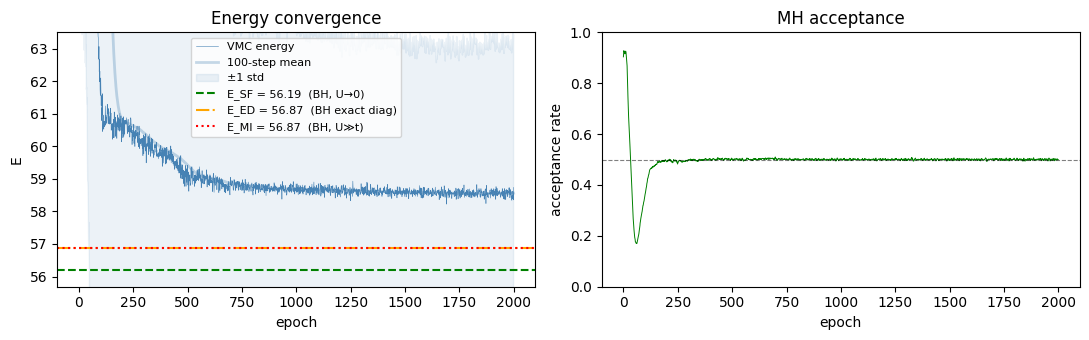

VMC energy (last 400 epochs): 58.5570 ± 0.0044
Best VMC energy (min std): 58.5722 ± 4.0519  (epoch 1748)
BH exact diag (full):            56.8713
Deviation:                       1.6857  (2.96%)


In [29]:
energies = np.array([float(s.energy) for s in result.history])
stds     = np.array([float(s.std)    for s in result.history])
acc      = np.array([float(s.acceptance_rate.mean()) for s in result.history])

win = 100
e_smooth = np.convolve(energies, np.ones(win) / win, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(energies, lw=0.4, alpha=1.0, color='steelblue', label='VMC energy')
axes[0].plot(np.arange(win - 1, len(energies)), e_smooth, lw=2, color='steelblue', alpha=0.3,
             label=f'{win}-step mean')
axes[0].fill_between(np.arange(0, len(energies)), energies - stds, energies + stds, alpha=0.1, color='steelblue', label='±1 std')
# Reference lines use full energies (N·ε₀ included) — same scale as VMC
axes[0].axhline(E_SF, color='g',      ls='--', lw=1.5, label=f'E_SF = {E_SF:.2f}  (BH, U→0)')
axes[0].axhline(E_ED, color='orange', ls='-.', lw=1.5, label=f'E_ED = {E_ED:.2f}  (BH exact diag)')
axes[0].axhline(E_MI, color='r',      ls=':',  lw=1.5, label=f'E_MI = {E_MI:.2f}  (BH, U≫t)')
axes[0].set(xlabel='epoch', ylabel='E', title='Energy convergence')
axes[0].legend(fontsize=8)
axes[0].set_ylim(E_SF-0.5, 63.5)

axes[1].plot(acc, lw=0.7, color='green')
axes[1].axhline(0.5, color='k', ls='--', lw=0.8, alpha=0.5)
axes[1].set(xlabel='epoch', ylabel='acceptance rate', title='MH acceptance', ylim=(0, 1))

plt.tight_layout(); plt.show()

tail = int(0.2 * N_EPOCHS)
E_VMC     = float(np.mean(energies[-tail:]))
E_VMC_std = float(np.std(energies[-tail:]) / np.sqrt(tail))
print(f"VMC energy (last {tail} epochs): {E_VMC:.4f} ± {E_VMC_std:.4f}")
print(f"Best VMC energy (min std): {energies[np.argmin(stds)]:.4f} ± {stds[np.argmin(stds)]:.4f}  (epoch {np.argmin(stds)})")
print(f"BH exact diag (full):            {E_ED:.4f}")
print(f"Deviation:                       {abs(E_VMC - E_ED):.4f}  ({abs(E_VMC-E_ED)/abs(E_ED)*100:.2f}%)")

---
## 9. Comparison: VMC vs Bose-Hubbard model

We place the VMC result on the BH phase diagram and compare to:
1. The superfluid limit $E_{\rm SF} = -2Nt$ (exact for $U=0$)
2. The Mott insulator limit $E_{\rm MI} \approx -4Nt^2/U$ (2nd-order perturbation)
3. Exact diagonalization of the BH Hamiltonian at the effective $(t, U)$

If the continuous model is well described by the BH model, VMC should agree with
the exact BH energy at the extracted $(t, U)$.

Residual deviations come from:
- **Multi-band effects** if $V_0/E_R$ is not large enough
- **Extended-range interactions** (the Gaussian has finite $\sigma$, unlike a true $\delta$)
- **VMC statistical error** (finite chain length and chain count)
- **Variational bias** (finite network expressivity)

  System: N=4, N_sites=4, V₀/Eᴿ=10.0, g_1D=0.01
  t = 0.09468,  U = 0.0200,  U/t = 0.21
  N·ε₀ = 56.9445  (lattice offset included in all values below)
  E_SF  (superfluid,  U→0)             = 56.1870
  E_MI  (Mott, 2nd order in t/U)       = 49.7769
  E_ED  (BH exact diag + N·ε₀)         = 56.2161
  E_VMC (neural-network VMC)            = 56.9905 ± 0.0060
  VMC vs ED: |ΔE| = 0.7744  (1.38%)

  Residual deviation comes from:
  • multi-band effects (higher bands not in BH model)
  • extended interactions (Gaussian σ > 0, not true δ-function)
  • variational bias (finite network expressivity)


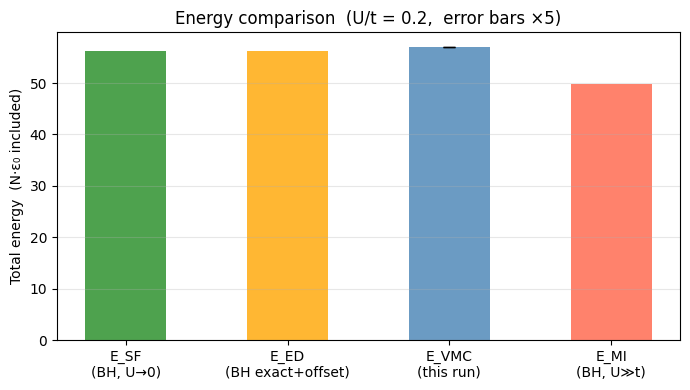

In [11]:
print("=" * 60)
print(f"  System: N={N}, N_sites={N_SITES}, V₀/Eᴿ={V0_ER}, g_1D={G_1D}")
print(f"  t = {T_EFF:.5f},  U = {U_EFF:.4f},  U/t = {U_EFF/T_EFF:.2f}")
print(f"  N·ε₀ = {N*E0_BAND:.4f}  (lattice offset included in all values below)")
print("=" * 60)
print(f"  E_SF  (superfluid,  U→0)             = {E_SF:.4f}")
print(f"  E_MI  (Mott, 2nd order in t/U)       = {E_MI:.4f}")
print(f"  E_ED  (BH exact diag + N·ε₀)         = {E_ED:.4f}")
print(f"  E_VMC (neural-network VMC)            = {E_VMC:.4f} ± {E_VMC_std:.4f}")
print("=" * 60)
print(f"  VMC vs ED: |ΔE| = {abs(E_VMC-E_ED):.4f}  ({abs(E_VMC-E_ED)/abs(E_ED)*100:.2f}%)")
print()
print("  Residual deviation comes from:")
print("  • multi-band effects (higher bands not in BH model)")
print("  • extended interactions (Gaussian σ > 0, not true δ-function)")
print("  • variational bias (finite network expressivity)")

# ── Bar chart ─────────────────────────────────────────────────────────────────
labels  = ['E_SF\n(BH, U→0)', 'E_ED\n(BH exact+offset)', 'E_VMC\n(this run)', 'E_MI\n(BH, U≫t)']
values  = [E_SF, E_ED, E_VMC, E_MI]
errors  = [0,    0,    E_VMC_std * 5, 0]   # ×5 for visibility
colours = ['forestgreen', 'orange', 'steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colours, alpha=0.8, width=0.5)
for bar, err in zip(bars, errors):
    if err > 0:
        ax.errorbar(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    yerr=err, fmt='none', color='k', capsize=4, lw=2)
ax.set(ylabel='Total energy  (N·ε₀ included)',
       title=f'Energy comparison  (U/t = {U_EFF/T_EFF:.1f},  error bars ×5)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---
## 11. Single-particle density

In the superfluid the density is nearly uniform (all bosons spread over all sites);
in the Mott insulator each boson is localised at a lattice site.

We sample the trained wavefunction from section 8 and histogram the particle positions.

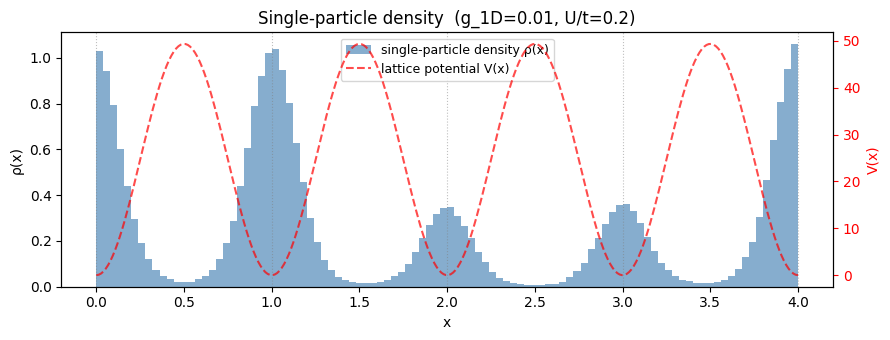

Fraction of particles near each site centre:
  site 0: 0.175  (uniform = 0.250)
  site 1: 0.350  (uniform = 0.250)
  site 2: 0.119  (uniform = 0.250)
  site 3: 0.123  (uniform = 0.250)


In [12]:
best_params = result.history[-1].params
prob_fn     = build_prob_fn(model.apply)

key_viz = jax.random.PRNGKey(7)
init_pos = jax.random.uniform(key_viz, (N_CHAINS, N)) * L

samples_viz, _, _ = sample_and_process(
    key=key_viz,
    prob_fn=prob_fn,
    prob_params=best_params,
    init_positions=init_pos,
    step_size=float(result.history[-1].step_size),
    n_chains=N_CHAINS,
    dof=N,
    n_steps=200,
    burn_in=50,
    thinning=5,
)

all_x = np.array(samples_viz).flatten() % L   # fold back to [0, L)

x_grid  = np.linspace(0, L, 300)
V_latt  = V0 * np.sin(np.pi * x_grid / A)**2

fig, ax = plt.subplots(figsize=(9, 3.5))
ax2 = ax.twinx()
ax.hist(all_x, bins=100, density=True, alpha=0.65, color='steelblue',
        label='single-particle density ρ(x)')
ax2.plot(x_grid, V_latt, 'r--', lw=1.5, alpha=0.7, label='lattice potential V(x)')

for j in range(N_SITES + 1):
    ax.axvline(j * A, color='gray', ls=':', lw=0.8, alpha=0.5)

ax.set(xlabel='x', ylabel='ρ(x)',
       title=f'Single-particle density  (g_1D={G_1D}, U/t={U_EFF/T_EFF:.1f})')
ax2.set_ylabel('V(x)', color='r'); ax2.tick_params(axis='y', colors='r')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
plt.tight_layout(); plt.show()

# Expected: for U/t >> 1 (Mott-like), four peaks at sites 0, 1, 2, 3;
#           for U/t << 1 (SF-like), nearly flat density.
site_peaks = [np.mean((all_x > j*A - 0.3) & (all_x < j*A + 0.3)) for j in range(N_SITES)]
print("Fraction of particles near each site centre:")
for j, p in enumerate(site_peaks):
    print(f"  site {j}: {p:.3f}  (uniform = {1/N_SITES:.3f})")

---
## 10. Crossover sweep: varying $g_{\rm 1D}$

By changing only `G_1D` (the interaction strength), we can sweep from the superfluid
to the Mott regime and verify that the VMC energy tracks the exact BH curve.

The code below runs three representative points: weak, intermediate, and strong
coupling. Each VMC run uses fewer epochs than the main run above to keep total
wall-clock time reasonable.

In [13]:
# ── Helper: run VMC for a given g_1D ──────────────────────────────────────────
def run_vmc_for_g(g_1d, n_epochs=5000, n_chains=2000, rng_seed=0):
    """Short VMC run for coupling g_1d.  Returns (E_VMC_full, sigma, U_eff)."""
    U_eff_local = g_1d * int_w4
    _boundary = PeriodicBoundary(L=L)

    h_local = LatticeBoseHamiltonian(
        a=A, V0=V0, g=g_1d, sigma=SIGMA,
        boundary=_boundary,
    )
    res = train(
        shape=(n_chains, N * N_DIM),
        model=LogWavefunction(
            n_particles=N,
            n_dim=N_DIM,
            transform=_boundary,
            # network=DeepSet(phi_hidden=[10], F_hidden=[10]),
            network=TransformerWavefunction(),
        ),
        optimizer=optax.adam(3e-3),
        hamiltonian=h_local,
        training_config=TrainingConfig(
            n_epochs=n_epochs,
            rng_seed=rng_seed,
            is_update_step_size=True,
            target_acceptance=0.5,
            checkpoint_path=f"./checkpoints/bh_g{g_1d:.1f}",
        ),
        sampler_params=SamplingConfig(
            step_size=0.3, chain_length=80, thermalization_steps=20, thinning_factor=2,
        ),
        coord_mode=LabCoords(),
    )
    tail = max(200, n_epochs // 5)
    E_tail = np.array([float(s.energy) for s in res.history[-tail:]])
    return float(np.mean(E_tail)), float(np.std(E_tail) / np.sqrt(len(E_tail))), U_eff_local


# Three coupling strengths spanning SF → MI crossover
g_sweep = [1e-3, 1e-2, 0.1, 0.5, 1, 2, 5, 10]

U_over_t_values = np.logspace(-2, 1, 10)
g_sweep = U_over_t_values * T_EFF / int_w4  # convert U/t to g_1D using U = g * int_w4

sweep_results = []
for g_val in g_sweep:
    U_v = g_val * int_w4
    print(f"g_1D = {g_val:.1f}  (U/t ≈ {U_v/T_EFF:.1e}) ...", end=" ")
    E_v, sigma_v, _ = run_vmc_for_g(g_val)
    E_bh_rel = bh_exact_diag(N, N_SITES, T_EFF, U_v)   # BH_relative
    E_bh     = N * E0_BAND + E_bh_rel                    # full energy
    sweep_results.append(dict(g=g_val, U_over_t=U_v/T_EFF,
                               E_VMC=E_v, sigma=sigma_v,
                               E_BH=E_bh, E_BH_rel=E_bh_rel))
    print(f"E_VMC={E_v:.4f},  E_BH_full={E_bh:.4f},  Δ={abs(E_v-E_bh):.4f}")


g_1D = 0.0  (U/t ≈ 1.0e-02) ... 

100%|██████████| 5000/5000 [18:54<00:00,  4.41it/s, E=56.2041, sigma_E=0.7541]   


E_VMC=56.2185,  E_BH_full=56.1884,  Δ=0.0300
g_1D = 0.0  (U/t ≈ 2.2e-02) ... 

100%|██████████| 5000/5000 [19:33<00:00,  4.26it/s, E=56.2086, sigma_E=0.4896]   


E_VMC=56.2115,  E_BH_full=56.1901,  Δ=0.0215
g_1D = 0.0  (U/t ≈ 4.6e-02) ... 

...

E_VMC=56.5104,  E_BH_full=56.4270,  Δ=0.0834
g_1D = 0.2  (U/t ≈ 4.6e+00) ... 

100%|██████████| 5000/5000 [18:37<00:00,  4.47it/s, E=56.7501, sigma_E=1.2314]   


E_VMC=56.7716,  E_BH_full=56.6065,  Δ=0.1651
g_1D = 0.5  (U/t ≈ 1.0e+01) ... 

100%|██████████| 5000/5000 [17:58<00:00,  4.64it/s, E=57.4968, sigma_E=2.4105]   


E_VMC=57.3601,  E_BH_full=56.7828,  Δ=0.5773


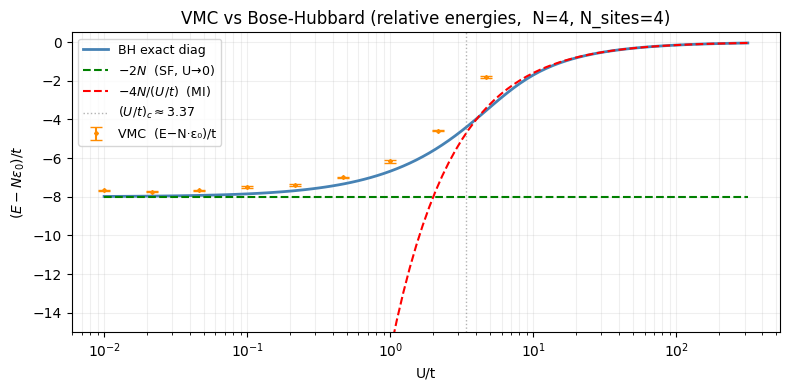


Summary table:
  g_1D     U/t       E_VMC   E_BH_full    |Δ|/|E_BH|
   0.0     0.0     56.2185     56.1884         0.05%
   0.0     0.0     56.2115     56.1901         0.04%
   0.0     0.0     56.2182     56.1936         0.04%
   0.0     0.1     56.2350     56.2010         0.06%
   0.0     0.2     56.2442     56.2166         0.05%
   0.0     0.5     56.2833     56.2487         0.06%
   0.0     1.0     56.3597     56.3118         0.09%
   0.1     2.2     56.5104     56.4270         0.15%
   0.2     4.6     56.7716     56.6065         0.29%
   0.5    10.0     57.3601     56.7828         1.02%


In [14]:
# ── Plot VMC sweep on the BH phase diagram (relative energies E/t) ────────────
# To place VMC points on the BH diagram (which shows E_BH_relative / t),
# we subtract N·ε₀ from E_VMC before dividing by t.

fig, ax = plt.subplots(figsize=(8, 4))

ut_plot   = np.logspace(-2, 2.5, 100)
E_ed_plot = np.array([bh_exact_diag(N, N_SITES, 1.0, ut) for ut in ut_plot])

ax.semilogx(ut_plot, E_ed_plot,                     'steelblue', lw=2,  label='BH exact diag')
ax.semilogx(ut_plot, -2*N*np.ones_like(ut_plot),    'g--',       lw=1.5, label=r'$-2N$  (SF, U→0)')
ax.semilogx(ut_plot, -4*N/ut_plot,                  'r--',       lw=1.5, label=r'$-4N/(U/t)$  (MI)')
ax.axvline(3.37, color='gray', ls=':', lw=1, alpha=0.6, label=r'$(U/t)_c\approx3.37$')

# VMC points: subtract N·ε₀ and divide by t to get BH_relative / t units
for res in sweep_results:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='D', ms=2, color='darkorange', capsize=4, zorder=5,
        label='VMC  (E−N·ε₀)/t' if res is sweep_results[0] else '_',
    )

ax.set(xlabel='U/t', ylabel='$(E - N\\varepsilon_0)/t$',
       title=f'VMC vs Bose-Hubbard (relative energies,  N={N}, N_sites={N_SITES})')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.2)
ax.set_ylim(-15, 0.5)
# ax.set_ylim(-10, 10)
plt.tight_layout(); plt.show()

print("\nSummary table:")
print(f"{'g_1D':>6}  {'U/t':>6}  {'E_VMC':>10}  {'E_BH_full':>10}  {'|Δ|/|E_BH|':>12}")
for res in sweep_results:
    rel = abs(res['E_VMC'] - res['E_BH']) / abs(res['E_BH']) * 100
    print(f"{res['g']:>6.1f}  {res['U_over_t']:>6.1f}  {res['E_VMC']:>10.4f}  "
          f"{res['E_BH']:>10.4f}  {rel:>11.2f}%")

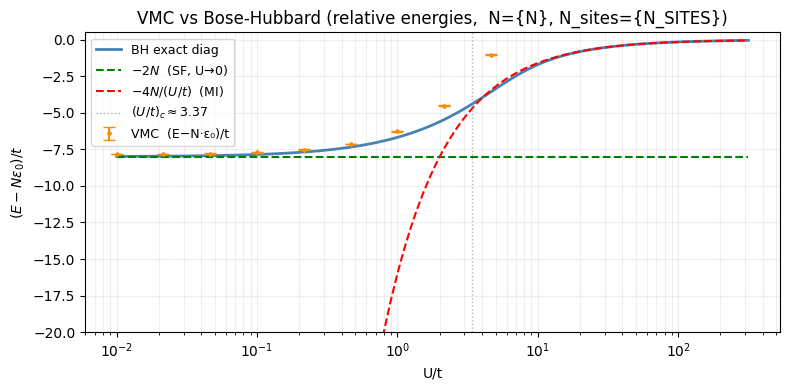


Summary table:
  g_1D     U/t       E_VMC   E_BH_full    |Δ|/|E_BH|
   0.0     0.0     56.2023     56.1884         0.02%
   0.0     0.0     56.2032     56.1901         0.02%
   0.0     0.0     56.2063     56.1936         0.02%
   0.0     0.1     56.2138     56.2010         0.02%
   0.0     0.2     56.2327     56.2166         0.03%
   0.0     0.5     56.2695     56.2487         0.04%
   0.0     1.0     56.3507     56.3118         0.07%
   0.1     2.2     56.5163     56.4270         0.16%
   0.2     4.6     56.8467     56.6065         0.42%
   0.5    10.0     57.4285     56.7828         1.14%


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(ut_plot, E_ed_plot,                     'steelblue', lw=2,  label='BH exact diag')
ax.semilogx(ut_plot, -2*N*np.ones_like(ut_plot),    'g--',       lw=1.5, label=r'$-2N$  (SF, U→0)')
ax.semilogx(ut_plot, -4*N/ut_plot,                  'r--',       lw=1.5, label=r'$-4N/(U/t)$  (MI)')
ax.axvline(3.37, color='gray', ls=':', lw=1, alpha=0.6, label=r'$(U/t)_c\approx3.37$')

# VMC points: subtract N·ε₀ and divide by t to get BH_relative / t units
for res in sweep_results:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='D', ms=2, color='darkorange', capsize=4, zorder=5,
        label='VMC  (E−N·ε₀)/t' if res is sweep_results[0] else '_',
    )

ax.set(xlabel='U/t', ylabel='$(E - N\\varepsilon_0)/t$',
       title=f'VMC vs Bose-Hubbard (relative energies,  N={N}, N_sites={N_SITES})')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.2)
ax.set_ylim(-20, 0.5)
# ax.set_ylim(-10, 10)
plt.tight_layout(); plt.show()

print("\nSummary table:")
print(f"{'g_1D':>6}  {'U/t':>6}  {'E_VMC':>10}  {'E_BH_full':>10}  {'|Δ|/|E_BH|':>12}")
for res in sweep_results:
    rel = abs(res['E_VMC'] - res['E_BH']) / abs(res['E_BH']) * 100
    print(f"{res['g']:>6.1f}  {res['U_over_t']:>6.1f}  {res['E_VMC']:>10.4f}  "
          f"{res['E_BH']:>10.4f}  {rel:>11.2f}%")

In [ ]:
# ── Helper: run VMC for a given g_1D ──────────────────────────────────────────
def run_vmc_for_g_bigger_model(g_1d, n_epochs=5000, n_chains=1000, rng_seed=0):
    """Short VMC run for coupling g_1d.  Returns (E_VMC_full, sigma, U_eff)."""
    U_eff_local = g_1d * int_w4
    _boundary = PeriodicBoundary(L=L)

    h_local = LatticeBoseHamiltonian(
        a=A, V0=V0, g=g_1d, sigma=SIGMA,
        boundary=_boundary,
    )
    res = train(
        shape=(n_chains, N * N_DIM),
        model=LogWavefunction(
            n_particles=N,
            n_dim=N_DIM,
            transform=_boundary,
            network=DeepSet(phi_hidden=[20], F_hidden=[20]),
        ),
        optimizer=optax.adam(3e-3),
        hamiltonian=h_local,
        training_config=TrainingConfig(
            n_epochs=n_epochs,
            rng_seed=rng_seed,
            is_update_step_size=True,
            target_acceptance=0.5,
            checkpoint_path=f"./checkpoints/bh_g{g_1d:.1f}",
        ),
        sampler_params=SamplingConfig(
            step_size=0.3, chain_length=80, thermalization_steps=20, thinning_factor=2,
        ),
        coord_mode=LabCoords(),
    )
    tail = max(200, n_epochs // 5)
    E_tail = np.array([float(s.energy) for s in res.history[-tail:]])
    return float(np.mean(E_tail)), float(np.std(E_tail) / np.sqrt(len(E_tail))), U_eff_local


# Three coupling strengths spanning SF → MI crossover

U_over_t_values = np.logspace(-2, 1, 10)[:5]
g_sweep_bigger_model = U_over_t_values * T_EFF / int_w4  # convert U/t to g_1D using U = g * int_w4

sweep_results_bigger_model = []
for g_val in g_sweep_bigger_model:
    U_v = g_val * int_w4
    print(f"g_1D = {g_val:.1e}  (U/t ≈ {U_v/T_EFF:.1e}) ...", end=" ")
    E_v, sigma_v, _ = run_vmc_for_g_bigger_model(g_val)
    E_bh_rel = bh_exact_diag(N, N_SITES, T_EFF, U_v)   # BH_relative
    E_bh     = N * E0_BAND + E_bh_rel                    # full energy
    sweep_results_bigger_model.append(dict(g=g_val, U_over_t=U_v/T_EFF,
                                           E_VMC=E_v, sigma=sigma_v,
                                           E_BH=E_bh, E_BH_rel=E_bh_rel))
    print(f"E_VMC={E_v:.4f},  E_BH_full={E_bh:.4f},  Δ={abs(E_v-E_bh):.4f}")


g_1D = 4.8e-04  (U/t ≈ 1.0e-02) ... 

 78%|███████▊  | 3913/5000 [01:25<00:23, 46.00it/s, E=112.5328, sigma_E=3.3278] 



Signal received, stopping after current step.


In [ ]:
# ── Plot VMC sweep on the BH phase diagram (relative energies E/t) ────────────
# To place VMC points on the BH diagram (which shows E_BH_relative / t),
# we subtract N·ε₀ from E_VMC before dividing by t.

fig, ax = plt.subplots(figsize=(8, 4))

ut_plot   = np.logspace(-2, 2.5, 100)
E_ed_plot = np.array([bh_exact_diag(N, N_SITES, 1.0, ut) for ut in ut_plot])

ax.semilogx(ut_plot, E_ed_plot,                     'steelblue', lw=2,  label='BH exact diag')
ax.semilogx(ut_plot, -2*N*np.ones_like(ut_plot),    'g--',       lw=1.5, label=r'$-2N$  (SF, U→0)')
ax.semilogx(ut_plot, -4*N/ut_plot,                  'r--',       lw=1.5, label=r'$-4N/(U/t)$  (MI)')
ax.axvline(3.37, color='gray', ls=':', lw=1, alpha=0.6, label=r'$(U/t)_c\approx3.37$')

# VMC points: subtract N·ε₀ and divide by t to get BH_relative / t units
for res in sweep_results:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='D', ms=2, color='darkorange', capsize=4, zorder=5,
        label='VMC  (E−N·ε₀)/t' if res is sweep_results[0] else '_',
    )
for res in sweep_results_bigger_model:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='o', ms=3, color='darkred', capsize=4, zorder=5, alpha=0.8,
        label='VMC bigger model' if res is sweep_results_bigger_model[0] else '_',
    )

ax.set(xlabel='U/t', ylabel='$(E - N\\varepsilon_0)/t$',
       title='VMC vs Bose-Hubbard (relative energies,  N=4, N_sites=4)')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.2)
ax.set_ylim(-8, 0.-6)
ax.set_xlim(0.005, 0.5)
plt.tight_layout(); plt.show()


In [ ]:
# ── Helper: run VMC for a given g_1D ──────────────────────────────────────────
def run_vmc_for_g_even_bigger_model(g_1d, n_epochs=5000, n_chains=2000, rng_seed=0):
    """Short VMC run for coupling g_1d.  Returns (E_VMC_full, sigma, U_eff)."""
    U_eff_local = g_1d * int_w4
    _boundary = PeriodicBoundary(L=L)

    h_local = LatticeBoseHamiltonian(
        a=A, V0=V0, g=g_1d, sigma=SIGMA,
        boundary=_boundary,
    )
    res = train(
        shape=(n_chains, N * N_DIM),
        model=LogWavefunction(
            n_particles=N,
            n_dim=N_DIM,
            transform=_boundary,
            network=DeepSet(phi_hidden=[128], F_hidden=[128], hidden_internal_dim=128),
        ),
        optimizer=optax.adam(3e-3),
        hamiltonian=h_local,
        training_config=TrainingConfig(
            n_epochs=n_epochs,
            rng_seed=rng_seed,
            is_update_step_size=True,
            target_acceptance=0.5,
            checkpoint_path=f"./checkpoints/bh_g{g_1d:.1f}",
        ),
        sampler_params=SamplingConfig(
            step_size=0.3, chain_length=80, thermalization_steps=20, thinning_factor=2,
        ),
        coord_mode=LabCoords(),
    )
    tail = max(200, n_epochs // 5)
    E_tail = np.array([float(s.energy) for s in res.history[-tail:]])
    return float(np.mean(E_tail)), float(np.std(E_tail) / np.sqrt(len(E_tail))), U_eff_local


# Three coupling strengths spanning SF → MI crossover

U_over_t_values = np.logspace(-2, 1, 10)[:5]
g_sweep_even_bigger_model = U_over_t_values * T_EFF / int_w4  # convert U/t to g_1D using U = g * int_w4

sweep_results_even_bigger_model = []
for g_val in g_sweep_even_bigger_model:
    U_v = g_val * int_w4
    print(f"g_1D = {g_val:.1e}  (U/t ≈ {U_v/T_EFF:.1e}) ...", end=" ")
    E_v, sigma_v, _ = run_vmc_for_g_even_bigger_model(g_val)
    E_bh_rel = bh_exact_diag(N, N_SITES, T_EFF, U_v)   # BH_relative
    E_bh     = N * E0_BAND + E_bh_rel                    # full energy
    sweep_results_even_bigger_model.append(dict(g=g_val, U_over_t=U_v/T_EFF,
                                           E_VMC=E_v, sigma=sigma_v,
                                           E_BH=E_bh, E_BH_rel=E_bh_rel))
    print(f"E_VMC={E_v:.4f},  E_BH_full={E_bh:.4f},  Δ={abs(E_v-E_bh):.4f}")


In [ ]:
# ── Plot VMC sweep on the BH phase diagram (relative energies E/t) ────────────
# To place VMC points on the BH diagram (which shows E_BH_relative / t),
# we subtract N·ε₀ from E_VMC before dividing by t.

fig, ax = plt.subplots(figsize=(8, 4))

ut_plot   = np.logspace(-2, 2.5, 100)
E_ed_plot = np.array([bh_exact_diag(N, N_SITES, 1.0, ut) for ut in ut_plot])

ax.semilogx(ut_plot, E_ed_plot,                     'steelblue', lw=2,  label='BH exact diag')
ax.semilogx(ut_plot, -2*N*np.ones_like(ut_plot),    'g--',       lw=1.5, label=r'$-2N$  (SF, U→0)')
ax.semilogx(ut_plot, -4*N/ut_plot,                  'r--',       lw=1.5, label=r'$-4N/(U/t)$  (MI)')
ax.axvline(3.37, color='gray', ls=':', lw=1, alpha=0.6, label=r'$(U/t)_c\approx3.37$')

# VMC points: subtract N·ε₀ and divide by t to get BH_relative / t units
for res in sweep_results:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='D', ms=2, color='darkorange', capsize=4, zorder=5,
        label='VMC  (E−N·ε₀)/t' if res is sweep_results[0] else '_',
    )
for res in sweep_results_bigger_model:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='o', ms=3, color='darkred', capsize=4, zorder=5, alpha=0.8,
        label='VMC bigger model' if res is sweep_results_bigger_model[0] else '_',
    )

for res in sweep_results_even_bigger_model:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='o', ms=4, color='darkgreen', capsize=4, zorder=5, alpha=0.8,
        label='VMC even bigger model' if res is sweep_results_even_bigger_model[0] else '_',
    )

ax.set(xlabel='U/t', ylabel='$(E - N\\varepsilon_0)/t$',
       title='VMC vs Bose-Hubbard (relative energies,  N=4, N_sites=4)')
ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.2)
ax.set_ylim(-8, 0.-6)
ax.set_xlim(0.005, 0.5)
plt.tight_layout(); plt.show()



In [ ]:
# ── Helper: run VMC for a given g_1D ──────────────────────────────────────────
def run_vmc_for_g_model_mlp(g_1d, n_epochs=5000, n_chains=1000, rng_seed=0):
    """Short VMC run for coupling g_1d.  Returns (E_VMC_full, sigma, U_eff)."""
    U_eff_local = g_1d * int_w4
    _boundary = PeriodicBoundary(L=L)

    h_local = LatticeBoseHamiltonian(
        a=A, V0=V0, g=g_1d, sigma=SIGMA,
        boundary=_boundary,
    )
    res = train(
        shape=(n_chains, N * N_DIM),
        model=LogWavefunction(
            # n_particles=N,
            # n_dim=N_DIM,
            transform=_boundary,
            network=MLP(hidden=[128, 128]),
        ),
        optimizer=optax.adam(3e-3),
        hamiltonian=h_local,
        training_config=TrainingConfig(
            n_epochs=n_epochs,
            rng_seed=rng_seed,
            is_update_step_size=True,
            target_acceptance=0.5,
            checkpoint_path=f"./checkpoints/bh_g{g_1d:.1f}",
        ),
        sampler_params=SamplingConfig(
            step_size=0.3, chain_length=80, thermalization_steps=20, thinning_factor=2,
        ),
        coord_mode=LabCoords(),
    )
    tail = max(200, n_epochs // 5)
    E_tail = np.array([float(s.energy) for s in res.history[-tail:]])
    return float(np.mean(E_tail)), float(np.std(E_tail) / np.sqrt(len(E_tail))), U_eff_local


# Three coupling strengths spanning SF → MI crossover

U_over_t_values = np.logspace(-2, 1, 10)[:5]
g_sweep_model_mlp = U_over_t_values * T_EFF / int_w4  # convert U/t to g_1D using U = g * int_w4

sweep_results_model_mlp = []
for g_val in g_sweep_model_mlp:
    U_v = g_val * int_w4
    print(f"g_1D = {g_val:.1e}  (U/t ≈ {U_v/T_EFF:.1e}) ...", end=" ")
    E_v, sigma_v, _ = run_vmc_for_g_model_mlp(g_val)
    E_bh_rel = bh_exact_diag(N, N_SITES, T_EFF, U_v)   # BH_relative
    E_bh     = N * E0_BAND + E_bh_rel                    # full energy
    sweep_results_model_mlp.append(dict(g=g_val, U_over_t=U_v/T_EFF,
                                           E_VMC=E_v, sigma=sigma_v,
                                           E_BH=E_bh, E_BH_rel=E_bh_rel))
    print(f"E_VMC={E_v:.4f},  E_BH_full={E_bh:.4f},  Δ={abs(E_v-E_bh):.4f}")


In [ ]:
# ── Plot VMC sweep on the BH phase diagram (relative energies E/t) ────────────
# To place VMC points on the BH diagram (which shows E_BH_relative / t),
# we subtract N·ε₀ from E_VMC before dividing by t.

fig, ax = plt.subplots(figsize=(10, 4))

ut_plot   = np.logspace(-2, 2.5, 100)
E_ed_plot = np.array([bh_exact_diag(N, N_SITES, 1.0, ut) for ut in ut_plot])

ax.semilogx(ut_plot, E_ed_plot,                     'steelblue', lw=2,  label='BH exact diag')
ax.semilogx(ut_plot, -2*N*np.ones_like(ut_plot),    'g--',       lw=1.5, label=r'$-2N$  (SF, U→0)')
ax.semilogx(ut_plot, -4*N/ut_plot,                  'r--',       lw=1.5, label=r'$-4N/(U/t)$  (MI)')
ax.axvline(3.37, color='gray', ls=':', lw=1, alpha=0.6, label=r'$(U/t)_c\approx3.37$')

# VMC points: subtract N·ε₀ and divide by t to get BH_relative / t units
for res in sweep_results:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='D', ms=2, color='darkorange', capsize=4, zorder=5,
        label='VMC  (E−N·ε₀)/t' if res is sweep_results[0] else '_',
    )
for res in sweep_results_bigger_model:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='o', ms=3, color='darkred', capsize=4, zorder=5, alpha=0.8,
        label='VMC bigger model' if res is sweep_results_bigger_model[0] else '_',
    )

for res in sweep_results_even_bigger_model:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='o', ms=4, color='darkgreen', capsize=4, zorder=5, alpha=0.8,
        label='VMC even bigger model' if res is sweep_results_even_bigger_model[0] else '_',
    )

for res in sweep_results_model_mlp:
    E_vmc_rel_t = (res['E_VMC'] - N * E0_BAND) / T_EFF
    ax.errorbar(
        res['U_over_t'], E_vmc_rel_t,
        yerr=res['sigma'] / T_EFF * 5,
        fmt='o', ms=5, color='purple', capsize=4, zorder=5, alpha=0.8,
        label='VMC model MLP' if res is sweep_results_model_mlp[0] else '_',
    )

ax.set(xlabel='U/t', ylabel='$(E - N\\varepsilon_0)/t$',
       title='VMC vs Bose-Hubbard (relative energies,  N=4, N_sites=4)')
ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.5, 1)); 
ax.grid(True, which='both', alpha=0.2)
ax.set_ylim(-8, -5)
ax.set_xlim(0.005, 0.5)
plt.tight_layout(); plt.show()



---
## Summary

| Quantity | Expression | Source |
|---|---|---|
| Recoil energy | $E_R = \pi^2/(2a^2)$ | units ($\hbar=m=1$) |
| Hopping $t$ | $t = [\varepsilon(\pi/a) - \varepsilon(0)]/4$ | band structure |
| On-site $U$ | $U = g_{\rm 1D}\int|w|^4 dx$ | Wannier function |
| Superfluid energy | $E_{\rm SF} = -2Nt$ | exact ($U=0$) |
| Mott energy | $E_{\rm MI} \approx -4Nt^2/U$ | 2nd-order perturbation |
| Phase boundary (1D, $\infty$) | $(U/t)_c \approx 3.37$ | DMRG |

The VMC simulation lives in **continuous space** and contains no second-quantisation
approximation. The agreement with the BH exact-diagonalization validates the
tight-binding mapping: for $V_0/E_R \gtrsim 3$, the lowest-band Hubbard model
correctly captures the physics.

**To explore deeper into the Mott regime:** increase `G_1D` until $U/t \gg 3.37$
and observe the density becoming peaked on individual sites.

**To improve the variational ansatz:** replace `LogMLP` with a
`DeepSet(n_particles=N, n_dim=2)` (permutation-invariant) and verify that
the energy lowers.

# Diagonalization

In [ ]:
import numpy as np
from scipy.sparse import diags, kron, eye, csr_matrix
from scipy.sparse.linalg import eigsh
from itertools import combinations



def diagonalize_continuum_nbody(V0, g_1D, a, L, N_grid, N_particles, sigma):
    """
    Diagonalize the N-body continuum Hamiltonian on [0,L) with PBC.

    H = -1/2 Σ_i ∂²_xi + V0 Σ_i sin²(πx_i/a) + g_1D Σ_{i<j} δ(x_i - x_j)

    Hilbert space dimension: N_grid^N_particles  (LARGE — use N<=3, N_grid<=30)
    """
    dx = L / N_grid
    x  = np.linspace(0, L, N_grid, endpoint=False, dtype=np.float32) # grid points for each particle
    dim = N_grid ** N_particles

    # ── 1D single-particle operator: h = -1/2 ∂² + V(x) ─────────────────
    diag_main = -2 * np.ones(N_grid, dtype=np.float32)
    diag_off  =      np.ones(N_grid - 1, dtype=np.float32)
    T1d = diags([diag_off, diag_main, diag_off], [-1, 0, 1],
                shape=(N_grid, N_grid), format='lil')
    T1d[0, -1] = 1.0  # PBC
    T1d[-1, 0] = 1.0  # PBC
    T1d = T1d.tocsr() * (-0.5 / dx**2)
    V1d = diags(V0 * np.sin(np.pi * x / a)**2)
    h   = T1d + V1d   # shape (N_grid, N_grid)

    # ── One-body terms: h acting on particle i ────────────────────────────
    # h_i = I⊗...⊗I⊗h⊗I⊗...⊗I  (h in the i-th slot)
    I = eye(N_grid, format='csr')

    def embed_operator_1b(op, particle_idx, N_particles, N_grid):
        """Embed 1-body operator op into N-body Hilbert space at particle_idx."""
        left  = N_grid ** particle_idx
        right = N_grid ** (N_particles - particle_idx - 1)
        return kron(kron(eye(left, format='csr'), op), eye(right, format='csr'))

    H = csr_matrix((dim, dim), dtype=np.float32)
    for i in range(N_particles):
        H += embed_operator_1b(h, i, N_particles, N_grid)

    # ── Two-body terms: g_1D δ(x_i - x_j) ───────────────────────────────
    # δ(x_i - x_j) ≈ (1/dx) * δ_{grid}(x_i - x_j)
    # In the tensor product basis, this is nonzero only when
    # particle i and j are on the same grid point.
    # Build as a sparse diagonal in the full N_grid^N space.

    def embed_interaction(i, j, N_particles, N_grid, dx):
        """
        Build the δ(x_i - x_j)/dx interaction between particles i and j.
        Nonzero only when grid indices of i and j coincide.
        """
        dim = N_grid ** N_particles
        # Iterate over all grid configurations, mark diagonal entries
        # where index i and index j are equal
        rows = []
        for flat_idx in range(dim):
            # Decode flat index into per-particle grid indices
            indices = []
            tmp = flat_idx
            for _ in range(N_particles):
                indices.append(tmp % N_grid)
                tmp //= N_grid
            if indices[i] == indices[j]:
                rows.append(flat_idx)
        data = np.ones(len(rows), dtype=np.float32) * (g_1D / dx)
        return csr_matrix((data, (rows, rows)), shape=(dim, dim))
    
    def embed_interaction_gaussian(i, j, N_particles, N_grid, x, g_1D, sigma):
        Xi, Xj = np.meshgrid(x, x, indexing='ij')
        V2d = (g_1D / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(Xi - Xj)**2 / (2 * sigma**2))
        # V2d is (N_grid, N_grid) — it acts on ONE particle's space
        # The two-particle operator is V2d ⊗_ij, meaning its matrix in the
        # joint (x_i, x_j) space is V2d[xi, xj] — already (N_grid, N_grid)
        # But we need it in the full N_grid^2 space of the pair:
        # M[xi*N_grid+xj, xi'*N_grid+xj'] = V2d[xi,xi'] * delta[xj,xj']  -- WRONG
        # Actually V(x_i,x_j) is a multiplicative operator:
        # M[xi,xj, xi',xj'] = V2d[xi,xj] * delta[xi,xi'] * delta[xj,xj']
        # i.e. it's DIAGONAL in the joint space

        dim    = N_grid ** N_particles
        n_rest = N_grid ** (N_particles - 2)

        # Build diagonal in the (x_i, x_j) joint space: shape (N_grid^2, N_grid^2)
        V2d_joint = diags(V2d.ravel())   # diagonal matrix, size N_grid^2

        # Now embed: V2d_joint acts on particles i,j; identity on rest
        # kron(V2d_joint, I_rest): shape (N_grid^2 * n_rest, N_grid^2 * n_rest)
        V_full = kron(V2d_joint, eye(n_rest, format='csr'))

        # Reshape and permute axes to put particles in right slots
        n_other   = N_particles - 2
        V_dense   = V_full.toarray().reshape(
            [N_grid, N_grid] + [N_grid] * n_other +
            [N_grid, N_grid] + [N_grid] * n_other
        )

        other     = [k for k in range(N_particles) if k != i and k != j]
        perm      = [i, j] + other
        iperm     = list(np.argsort(perm))
        full_perm = iperm + [p + N_particles for p in iperm]

        V_dense = V_dense.transpose(full_perm).reshape(dim, dim)
        return csr_matrix(V_dense)

    for i, j in combinations(range(N_particles), 2):
        H += embed_interaction_gaussian(i, j, N_particles, N_grid, x, g_1D, sigma)

    # ── Diagonalize ───────────────────────────────────────────────────────
    E_vals, E_vecs = eigsh(H, k=min(6, dim - 1), which='SM')
    idx = np.argsort(E_vals)
    return E_vals[idx], E_vecs[:, idx], x, dx

eigenvals, eigenvecs, x_grid, dx = diagonalize_continuum_nbody(V0, G_1D, A, L, N_grid=15, N_particles=N, sigma=SIGMA)

In [ ]:
print(eigenvals)

In [ ]:
import numpy as np
from scipy.sparse import diags, kron, eye, csr_matrix
from scipy.sparse.linalg import eigsh
from itertools import combinations


def diagonalize_continuum_nbody(V0, g_1D, a, L, N_grid, N_particles, sigma,
                                dtype=np.float32):
    """
    Diagonalize the N-body continuum Hamiltonian on [0,L) with PBC.

    H = -1/2 Σ_i ∂²_xi + V0 Σ_i sin²(πx_i/a) + g_1D Σ_{i<j} V_gauss(x_i-x_j)

    Hilbert space dimension: N_grid^N_particles
    Practical limits: N<=3 with N_grid<=30, or N=4 with N_grid<=10.
    """
    dx  = dtype(L / N_grid)
    x   = np.linspace(0, L, N_grid, endpoint=False).astype(dtype)
    dim = N_grid ** N_particles

    # ── 1D single-particle operator: h = -1/2 ∂² + V(x) ──────────────────
    diag_main = np.full(N_grid,     -2.0, dtype=dtype)
    diag_off  = np.ones(N_grid - 1,       dtype=dtype)
    T1d = diags([diag_off, diag_main, diag_off], [-1, 0, 1],
                shape=(N_grid, N_grid), format='lil', dtype=dtype)
    T1d[0, -1] = dtype(1.0)   # PBC
    T1d[-1, 0] = dtype(1.0)   # PBC
    T1d = T1d.tocsr().astype(dtype) * dtype(-0.5 / dx**2)

    V1d = diags((V0 * np.sin(np.pi * x / a)**2).astype(dtype), dtype=dtype)
    h   = (T1d + V1d).astype(dtype)

    # ── One-body terms: Σ_i h_i = Σ_i I⊗...⊗h⊗...⊗I ─────────────────────
    def embed_1b(op, p):
        """Embed 1-body operator op at particle slot p."""
        left  = eye(N_grid ** p,                      format='csr', dtype=dtype)
        right = eye(N_grid ** (N_particles - p - 1),  format='csr', dtype=dtype)
        return kron(kron(left, op.astype(dtype)), right, format='csr')

    H = csr_matrix((dim, dim), dtype=dtype)
    for p in range(N_particles):
        H = (H + embed_1b(h, p)).astype(dtype)

    # ── Two-body terms: Σ_{i<j} V_gauss(x_i - x_j) ───────────────────────
    def embed_interaction_gaussian(i, j):
        """
        Gaussian-smeared contact interaction between particles i and j.
        V(x_i, x_j) = g_1D/(σ√2π) * exp(-(x_i-x_j)²/2σ²)
        This is a multiplicative operator — diagonal in position space.
        """
        Xi, Xj = np.meshgrid(x, x, indexing='ij')
        V2d = (g_1D / (sigma * np.sqrt(2 * np.pi))) * \
              np.exp(-(Xi - Xj)**2 / (2 * sigma**2))
        V2d = V2d.astype(dtype)

        # V(x_i,x_j) is diagonal in the joint (x_i,x_j) basis:
        # <xi,xj|V|xi',xj'> = V2d[xi,xj] * δ_{xi,xi'} * δ_{xj,xj'}
        n_rest    = N_grid ** (N_particles - 2)
        V2d_joint = diags(V2d.ravel(), dtype=dtype)  # (N_grid², N_grid²) diagonal

        # Embed: V2d_joint on (i,j) slots, identity on rest
        V_full = kron(V2d_joint,
                      eye(n_rest, format='csr', dtype=dtype),
                      format='csr')
        # V_full has shape (N_grid² * n_rest, N_grid² * n_rest) = (dim, dim)

        # Reshape into per-particle axes so we can permute i,j to correct slots
        n_other   = N_particles - 2
        V_dense   = V_full.toarray().reshape(
            [N_grid, N_grid] + [N_grid] * n_other +   # bra axes
            [N_grid, N_grid] + [N_grid] * n_other      # ket axes
        )
        # Current axis order: bra=(i=0, j=1, other_0=2, ...), ket=(i, j, other_0, ...)
        # Target axis order: bra=(0,1,...,N-1),               ket=(0,1,...,N-1)
        other     = [k for k in range(N_particles) if k != i and k != j]
        perm      = [i, j] + other           # current slot -> target slot
        iperm     = list(np.argsort(perm))   # target slot  -> current slot
        full_perm = iperm + [p + N_particles for p in iperm]

        V_dense = V_dense.transpose(full_perm).reshape(dim, dim).astype(dtype)
        return csr_matrix(V_dense, dtype=dtype)

    for i, j in combinations(range(N_particles), 2):
        H = (H + embed_interaction_gaussian(i, j)).astype(dtype)

    # ── Diagonalize ────────────────────────────────────────────────────────
    # eigsh needs float64 internally — cast H temporarily
    E_vals, E_vecs = eigsh(H.astype(np.float64), k=min(6, dim - 1), which='SM')
    idx = np.argsort(E_vals)
    return E_vals[idx], E_vecs[:, idx], x, dx

eigenvals, eigenvecs, x_grid, dx = diagonalize_continuum_nbody(
    V0=V0, g_1D=G_1D, a=A, L=L, N_grid=13, N_particles=N, sigma=SIGMA, dtype=np.float32)
print("Eigenvalues (continuum diagonalization):")
print(eigenvals)

In [ ]:
smallest_eigval = []

for value in [7,8,9,10,11,12,13]:
    eigenvals, _, _, _ = diagonalize_continuum_nbody(
        V0=V0, g_1D=G_1D, a=A, L=L, N_grid=value, N_particles=N, sigma=SIGMA, dtype=np.float32)
    smallest_eigval.append(eigenvals[0])


import matplotlib.pyplot as plt
plt.plot([7,8,9,10,11,12,13], smallest_eigval, marker='o')
plt.xlabel('N_grid')
plt.ylabel('Smallest eigenvalue')
plt.title('Convergence of smallest eigenvalue with grid size')

In [ ]:
print(f"V0={V0}, G_1D={G_1D}, A={A}, L={L}, N_grid={15}, N_particles={N}, sigma={SIGMA}")

In [ ]:
new_eigenvals, _, _, _ = diagonalize_continuum_nbody(
    V0=V0, g_1D=G_1D, a=A, L=L, N_grid=14, N_particles=N, sigma=SIGMA, dtype=np.float32)
smallest_eigval.append(new_eigenvals[0])
# smallest_eigval.append(32.869412643050914)
# smallest_eigval.append(32.792907754329036)


# plt.plot([7,8,9,10,11,12,13,14, 15, 16], smallest_eigval, marker='o', label='Smallest eigenvalue')
plt.plot([7,8,9,10,11,12,13,14], smallest_eigval, marker='o', label='Smallest eigenvalue')
plt.xlabel('N_grid')
plt.ylabel('Smallest eigenvalue')
plt.title('Convergence of smallest eigenvalue with grid size')
plt.legend()
plt.tight_layout()
plt.show()